# library

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import pandas as pd
import os,sys
import seaborn as sns
from scipy import sparse
import matplotlib.cm as cm
import biolucid 
from tidyi import tidyi_main_mouse
from scipy.stats import pearsonr
from pathlib import Path
import harmonypy as hm

# loading data

In [2]:
# loading mukin skin data annotated by ASTRID
MUKIN_SK_ASTRID_DIR = Path('/scratch/chenxi.sun/thesis_project/mukin_qcdata/AllRef_skin_0204')

def load_merge_adata(data_dir, file_pattern='*outASTRID.h5ad'):
    """Load one ASTRID h5ad per sample subdirectory and merge them."""
    data_dir = Path(data_dir)
    adatas = []

    for sample_dir in sorted(p for p in data_dir.iterdir() if p.is_dir()):
        files = sorted(sample_dir.glob(file_pattern))
        if files:
            adatas.append(sc.read_h5ad(files[0]))

    if not adatas:
        raise FileNotFoundError(f'No {file_pattern} files found under {data_dir}')

    return adatas[0].concatenate(adatas[1:], join='inner')

mukin_sk_astrid = load_merge_adata(MUKIN_SK_ASTRID_DIR)

print(mukin_sk_astrid)

AnnData object with n_obs × n_vars = 48267 × 19891
    obs: 'Sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'doublet_score', 'predicted_doublet', 'tissue', 'model', 'age', 'mouseID', 'cell_type_lvl1', 'cell_type_lvl2', 'cell_type_lvl3', 'cellType', 'clustering_level_1', 'clustering_level_2', 'clustering_level_3', 'clustering_level_4', 'clustering_level_5', 'clustering_level_6', 'clustering_level_7', 'clustering_level_8', 'clustering_level_9', 'final_clustering_level', 'SingleR_Pruned_CellType', 'SingleR_All_deltanext', 'SingleR_CellType', 'batch'
    obsm: 'X_pca', 'X_pca_norm_counts', 'X_umap'
    layers: 'norm_counts', 'raw'


# using the annotation method in human skin data to annotate mice skin 

In [5]:
mukin_sk_astrid.obs['SingleR_CellType'].unique().tolist()

['keratinocyte basal label retain',
 'keratinocyte proliferating',
 'keratinocyte spinosum upper',
 'T epithelium',
 'langerhans',
 'hair follicle bulge',
 'keratinocyte granulosum',
 'hair follicle',
 'sebocyte',
 'keratinocyte spinosum suprabasal',
 'keratinocyte basal early response',
 'Treg',
 'hair follicle quiescent']

In [ ]:
mukin_merge = mukin_sk_astrid.copy()
mukin_merge.X = mukin_merge.layers['raw'].copy()

sc.pp.filter_cells(mukin_merge, min_genes=200)
sc.pp.filter_genes(mukin_merge, min_cells=3)

sc.pp.normalize_total(mukin_merge, target_sum=1e6)
sc.pp.log1p(mukin_merge)
mukin_merge.layers['logTPM'] = mukin_merge.X.copy()

sc.pp.highly_variable_genes(mukin_merge, n_top_genes=2000, batch_key='Sample')
sc.tl.pca(mukin_merge)

harmony_out = hm.run_harmony(
    mukin_merge.obsm['X_pca'],
    mukin_merge.obs,
    'Sample',
)

Z_corr = np.asarray(harmony_out.Z_corr)
if Z_corr.shape != mukin_merge.obsm['X_pca'].shape:
    Z_corr = Z_corr.T
mukin_merge.obsm['X_pca_harmony'] = Z_corr

sc.pp.neighbors(mukin_merge, use_rep='X_pca_harmony')
sc.tl.umap(mukin_merge)
sc.tl.leiden(mukin_merge, flavor='igraph', n_iterations=2)

mukin_merge

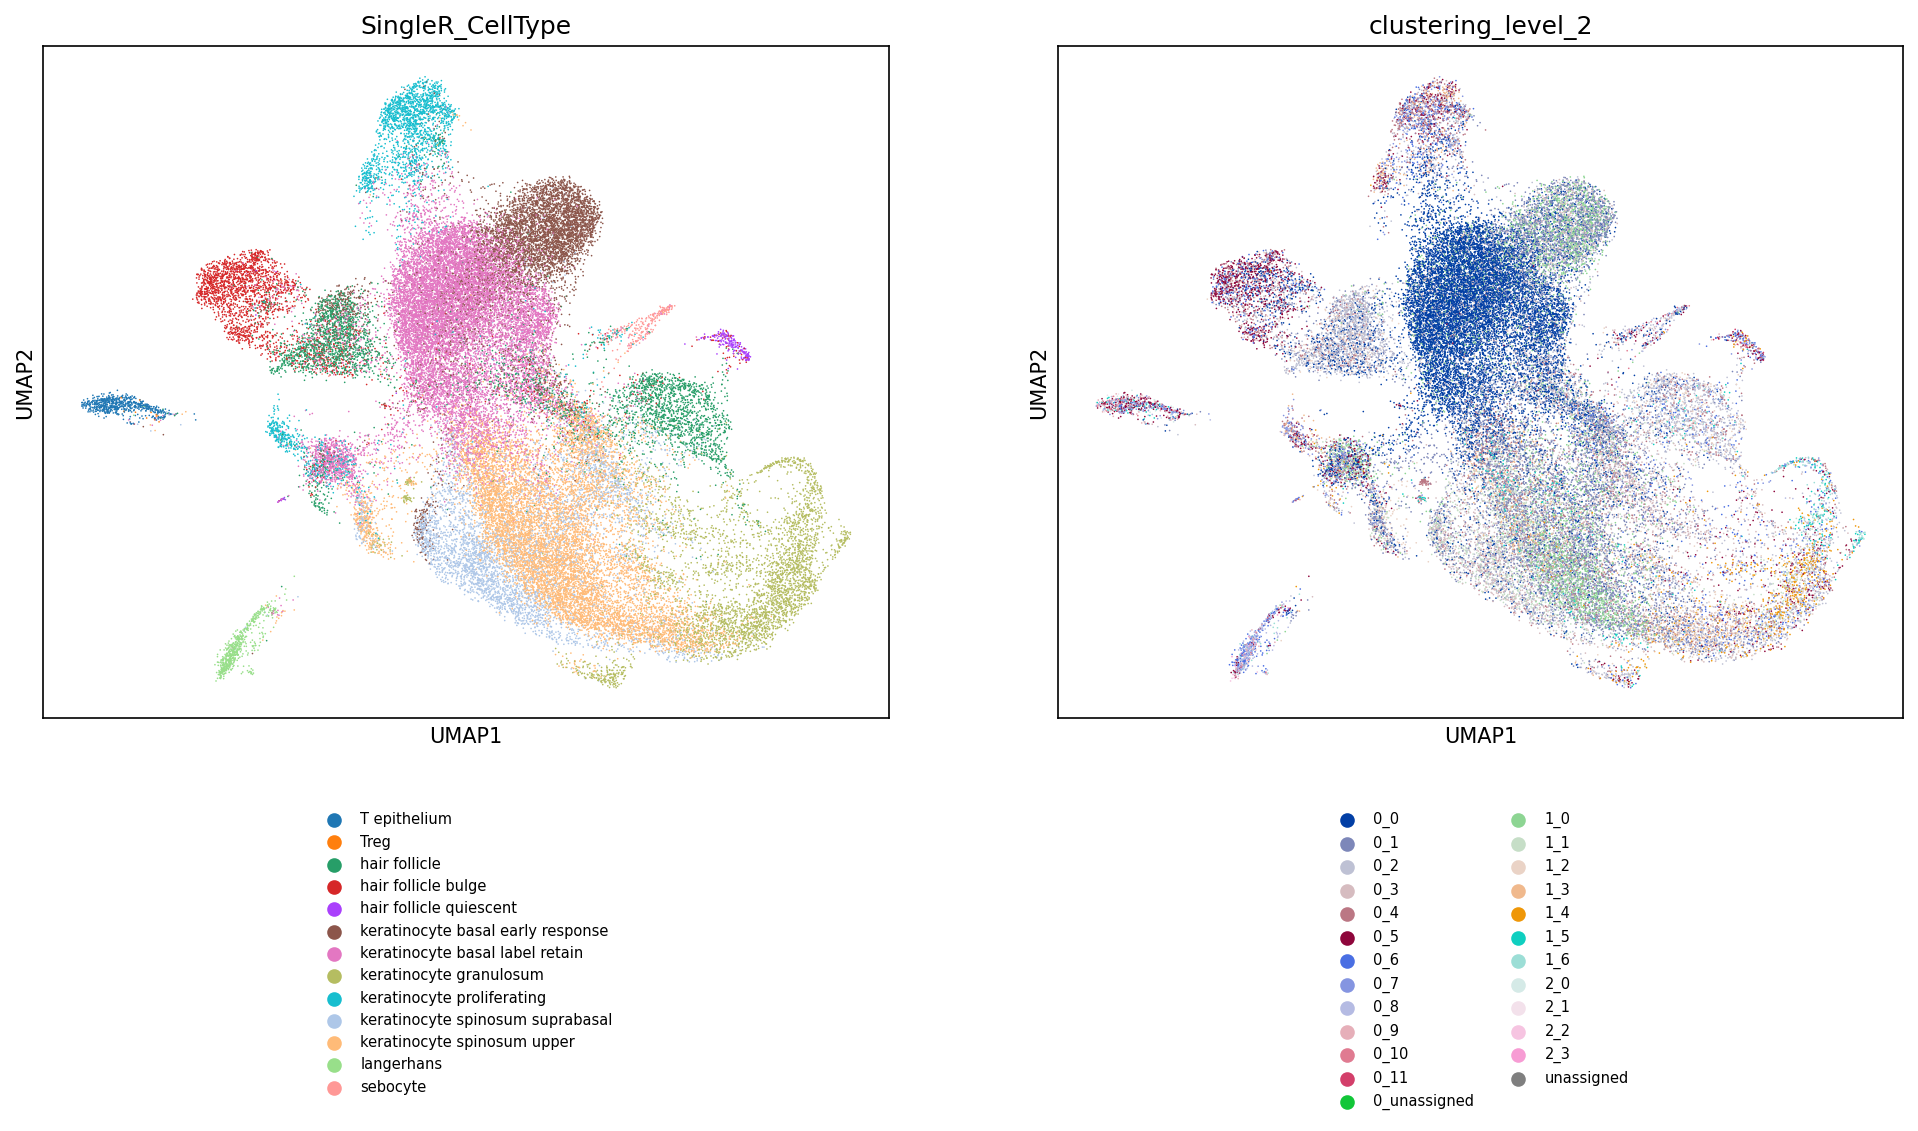

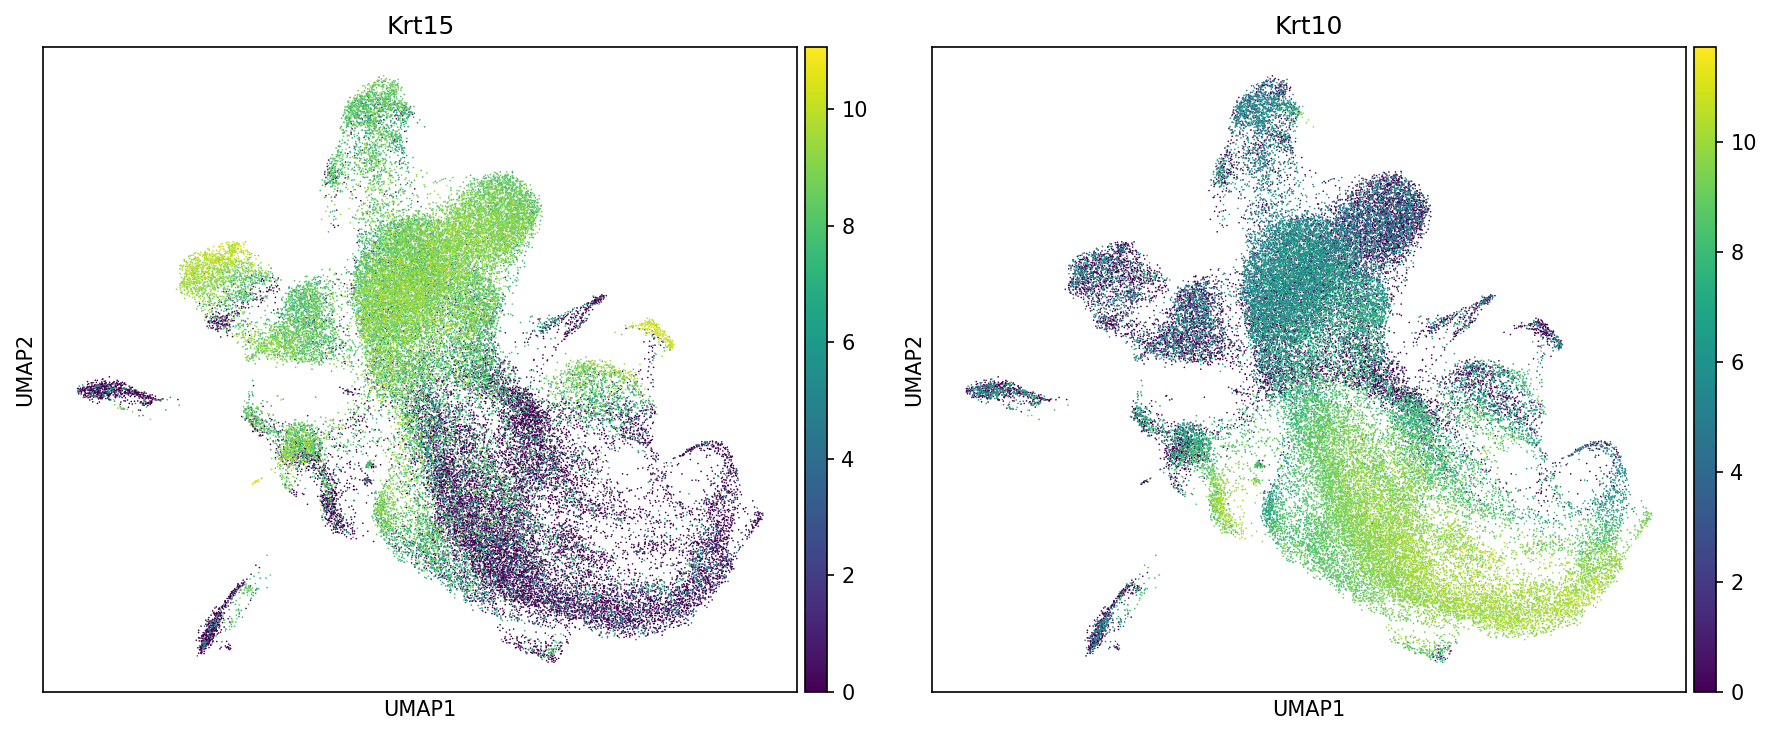

In [20]:
marker_genes = ['Krt15', 'Krt10']
output_dir = Path('/scratch/chenxi.sun/RA project/rates reproduce/skin_validation_output')
output_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=150)
for ax, color, title in zip(axes, ['SingleR_CellType', 'clustering_level_2'], ['SingleR_CellType', 'clustering_level_2']):
    sc.pl.umap(
        mukin_merge,
        color=color,
        ax=ax,
        show=False,
        legend_loc='right margin',
        legend_fontsize=7,
        title=title,
    )
    legend = ax.get_legend()
    if legend is not None:
        legend.set_bbox_to_anchor((0.5, -0.12))
        legend._loc = 9
        legend.set_frame_on(False)
        legend.set_ncols(3)

fig.subplots_adjust(bottom=0.32, wspace=0.2)
fig.savefig(output_dir / 'mukin_skin_umap_annotation_leiden.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)
for ax, gene in zip(axes, marker_genes):
    sc.pl.umap(
        mukin_merge,
        color=gene,
        ax=ax,
        show=False,
        color_map='viridis',
        title=gene,
    )

fig.tight_layout()
fig.savefig(output_dir / 'mukin_skin_umap_krt15_krt10.png', dpi=300, bbox_inches='tight')
plt.show()

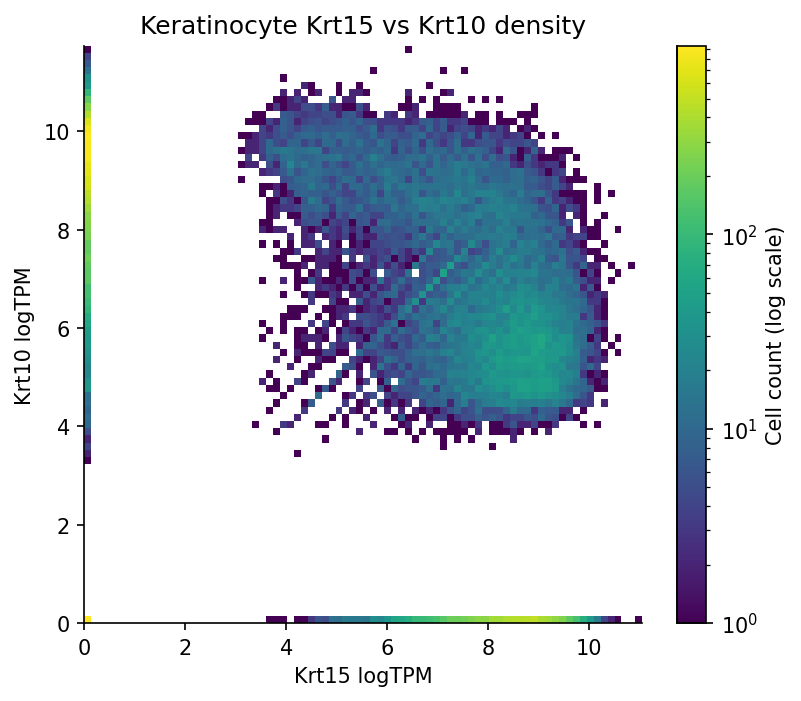

keratinocytes: 40632


In [27]:
keratinocyte_mask = mukin_merge.obs['SingleR_CellType'].astype(str).str.contains('keratinocyte', case=False, na=False)
mukin_kc = mukin_merge[keratinocyte_mask].copy()
mukin_kc.layers['logTPM'] = mukin_kc.layers.get('logTPM', mukin_kc.X.copy())
kc_expr = sc.get.obs_df(mukin_kc, keys=['Krt15', 'Krt10'], layer='logTPM')

from matplotlib.colors import LogNorm

fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
hist = ax.hist2d(
    kc_expr['Krt15'],
    kc_expr['Krt10'],
    bins=80,
    cmap='viridis',
    norm=LogNorm(),
)
fig.colorbar(hist[3], ax=ax, label='Cell count (log scale)')

ax.set_xlabel('Krt15 logTPM')
ax.set_ylabel('Krt10 logTPM')
ax.set_title('Keratinocyte Krt15 vs Krt10 density')
sns.despine()
plt.show()

print(f'keratinocytes: {mukin_kc.n_obs}')

In [26]:
mukin_kc

AnnData object with n_obs × n_vars = 40632 × 19881
    obs: 'Sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'doublet_score', 'predicted_doublet', 'tissue', 'model', 'age', 'mouseID', 'cell_type_lvl1', 'cell_type_lvl2', 'cell_type_lvl3', 'cellType', 'clustering_level_1', 'clustering_level_2', 'clustering_level_3', 'clustering_level_4', 'clustering_level_5', 'clustering_level_6', 'clustering_level_7', 'clustering_level_8', 'clustering_level_9', 'final_clustering_level', 'SingleR_Pruned_CellType', 'SingleR_All_deltanext', 'SingleR_CellType', 'batch', 'leiden'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap

kc_human_validation
differentiated    23206
progenitor        17426
Name: count, dtype: int64

SingleR_CellType
keratinocyte basal label retain      14672
keratinocyte spinosum upper          10080
keratinocyte basal early response     5606
keratinocyte spinosum suprabasal      4323
keratinocyte granulosum               3599
keratinocyte proliferating            2352
Name: count, dtype: int64

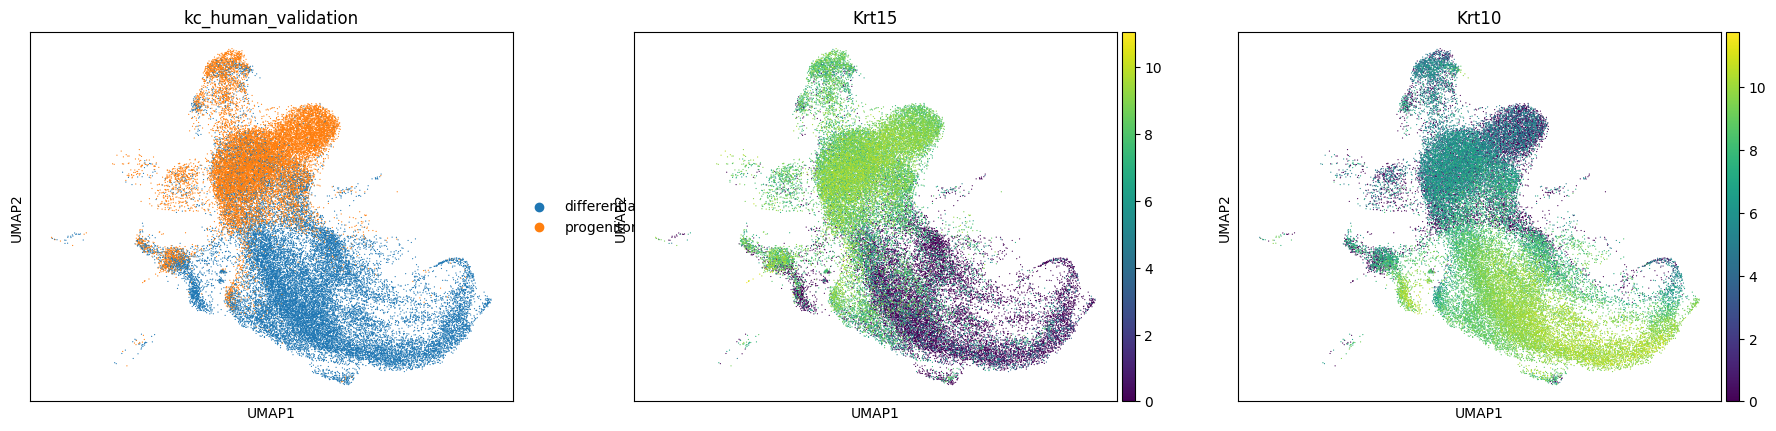

In [28]:
mukin_kc.layers['logTPM'] = mukin_kc.layers.get('logTPM', mukin_kc.X.copy())
kc_expr = sc.get.obs_df(mukin_kc, keys=['Krt15', 'Krt10'], layer='logTPM')

mukin_kc.obs['kc_human_validation'] = np.where(
    kc_expr['Krt10'] > kc_expr['Krt15'] - 1.2,
    'differentiated',
    'progenitor',
)

display(mukin_kc.obs['kc_human_validation'].value_counts())
display(mukin_kc.obs['SingleR_CellType'].value_counts())

sc.pl.umap(
    mukin_kc,
    color=['kc_human_validation', 'Krt15', 'Krt10'],
    layer='logTPM',
    color_map='viridis',
    ncols=3,
    legend_loc='right margin',
)

In [29]:
mukin_kc.obs

,Sample,n_genes,n_genes_by_counts,total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,pct_counts_mt,...,clustering_level_7,clustering_level_8,clustering_level_9,final_clustering_level,SingleR_Pruned_CellType,SingleR_All_deltanext,SingleR_CellType,batch,leiden,kc_human_validation
AAACCTGAGACAGACC-1-0,A210,450,450,761.0,45.729304,54.007884,67.148489,100.000000,165.0,21.681997,...,1_0_1_2_0_0_0,1_0_1_2_0_0_0,1_0_1_2_0_0_0,1_0_1_2_0_0_0,NaN,0.581360,keratinocyte basal label retain,0,0,differentiated
AAACCTGAGCCACTAT-1-0,A210,687,687,1026.0,27.582846,38.986355,52.534113,81.773879,71.0,6.920078,...,0_0_0_0_1_1_1,0_0_0_0_1_1_1,0_0_0_0_1_1_1,0_0_0_0_1_1_1,keratinocyte basal label retain,0.076005,keratinocyte basal label retain,0,0,differentiated
AAACCTGAGGTGATTA-1-0,A210,2548,2548,6638.0,24.043387,36.065080,47.845737,63.407653,180.0,2.711660,...,0_2_1_2,0_2_1_2,0_2_1_2,0_2_1_2,keratinocyte proliferating,1.058467,keratinocyte proliferating,0,2,progenitor
AAACCTGCATACTACG-1-1-0,A210,1766,1766,4590.0,34.313725,47.516340,58.104575,72.200436,316.0,6.884531,...,1_0_0_1_2_0_1,1_0_0_1_2_0_1,1_0_0_1_2_0_1,1_0_0_1_2_0_1,keratinocyte spinosum upper,0.059959,keratinocyte spinosum upper,0,4,differentiated
AAACCTGGTCACTTCC-1-0,A210,1523,1523,4393.0,44.434327,58.137947,66.241748,76.712952,211.0,4.803096,...,0_0_1,0_0_1,0_0_1,0_0_1,keratinocyte basal label retain,0.097688,keratinocyte basal label retain,0,9,progenitor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTGTTTAGCTG-1-11,A068,465,465,784.0,36.352041,50.637755,66.198980,100.000000,0.0,0.000000,...,0_7_0_1,0_7_0_1,NaN,0_7_0_1,keratinocyte proliferating,0.061762,keratinocyte proliferating,11,14,differentiated
TTTGTCAAGGGCATGT-1-11,A068,4017,4017,20106.0,34.815478,47.607679,58.768527,70.158162,514.0,2.556451,...,1_0_1_0_0,1_0_1_0_0,NaN,1_0_1_0_0,keratinocyte spinosum upper,0.070961,keratinocyte spinosum upper,11,7,differentiated
TTTGTCAAGTCTTGCA-1-1-11,A068,3381,3381,16055.0,37.085020,52.457178,62.653379,73.553410,459.0,2.858922,...,1_0_2_0_0,1_0_2_0_0,NaN,1_0_2_0_0,keratinocyte spinosum upper,0.060749,keratinocyte spinosum upper,11,4,differentiated
TTTGTCAGTAAGTAGT-1-1-11,A068,2210,2210,7097.0,33.352121,48.795266,59.701282,72.269973,362.0,5.100747,...,0_0_1_1_1,0_0_1_1_1,NaN,0_0_1_1_1,keratinocyte basal label retain,0.080330,keratinocyte basal label retain,11,10,progenitor


/scratch/common/miniconda3/envs/scx_py310/lib/python3.10/site-packages/tidyi/tidyi_main_mouse.py:31: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  mouse_10x.var['gene_id_human'] = [mouse_to_human[gene] for gene in mouse_10x.var['gene_id_mouse']]


Number of genes: 10687


/scratch/common/miniconda3/envs/scx_py310/lib/python3.10/site-packages/tidyi/tidyi_main_mouse.py:51: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  mouse_ss3.var['gene_id_human'] = [mouse_to_human[gene] for gene in mouse_ss3.var['gene_id_mouse']]


Number of genes used for analysis:  10438


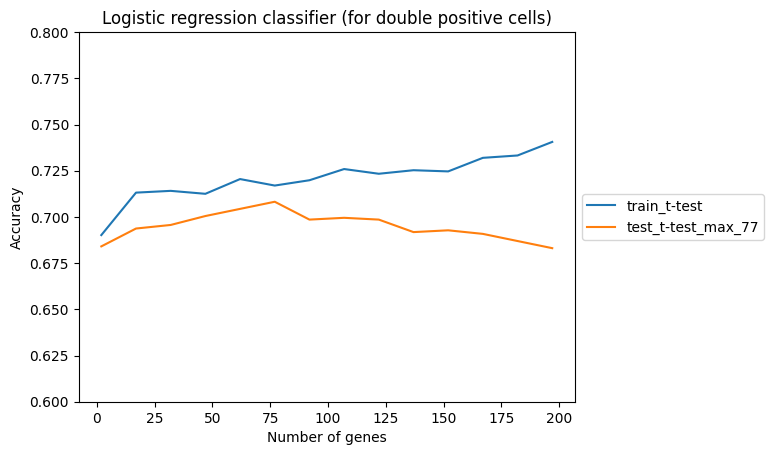

Best number of genes: 77
Best accuracy: 0.7082125603864734


adata.X seems to be already log-transformed.


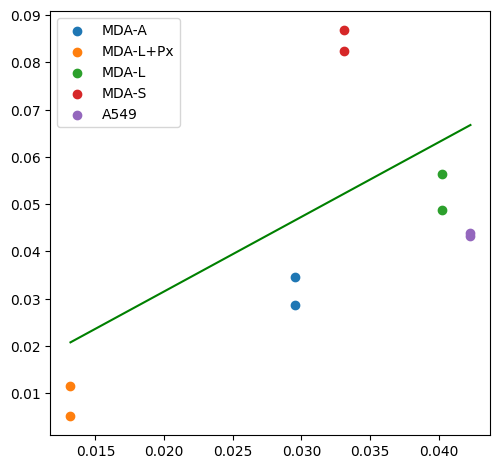

Proportionality factor death: 0.634079884203096


adata.X seems to be already log-transformed.


Only  63  genes out of  74  were found in the dataset


/scratch/common/miniconda3/envs/scx_py310/lib/python3.10/site-packages/tidyi/tidyi_main.py:247: RuntimeWarning: overflow encountered in exp
  scores = [1/(1+np.exp(-a*(s-b))) for s in scores]


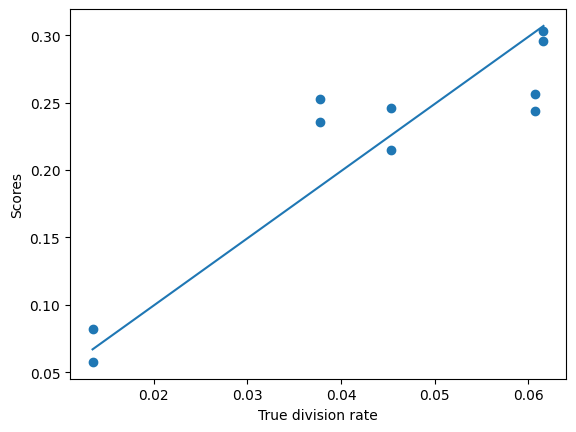

Proportionality factor division: 0.20077232498529773
Accuracies test,train for mouse  0.8071428571428572 0.8066914498141264


/scratch/common/miniconda3/envs/scx_py310/lib/python3.10/site-packages/tidyi/tidyi_main.py:85: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  dat.X = dat.layers['counts'].copy()
/home/chenxi.sun/.local/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
adata.X seems to be already log-transformed.
adata.X seems to be already log-transformed.


Dying fraction: 0.0007504998793891907


adata.X seems to be already log-transformed.


Dying fraction new: 0.17904697557522142
Proportionality factor division: 0.5107557359308181
Proportionality factor death: 0.4169363098530226


/scratch/common/miniconda3/envs/scx_py310/lib/python3.10/site-packages/tidyi/tidyi_main.py:85: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  dat.X = dat.layers['counts'].copy()
/home/chenxi.sun/.local/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
adata.X seems to be already log-transformed.
adata.X seems to be already log-transformed.
/scratch/common/miniconda3/envs/scx_py310/lib/python3.10/site-packages/tidyi/tidyi_main.py:85: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  dat.X = dat.layers['counts'].copy()
/home/chenxi.sun/.local/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
adata.X seems to be already log-transformed.
adata.X seems to be already log-transformed.
/scratch/common/minico

,mouseID,kc_human_validation,proliferation_rate,death_rate,n_cells
0,GF_19m_1,differentiated,0.008543,0.030876,3705
1,GF_19m_1,progenitor,0.015211,0.025687,2606
2,GF_19m_2,progenitor,0.017113,0.021109,1308
3,GF_19m_2,differentiated,0.009830,0.030505,1760
4,GF_19m_3,differentiated,0.008696,0.030112,2076
5,GF_19m_3,progenitor,0.015619,0.018038,1706
6,GF_2m_1,differentiated,0.005422,0.024524,2028
7,GF_2m_1,progenitor,0.012980,0.023053,1244
8,GF_2m_2,differentiated,0.011769,0.031009,964
9,GF_2m_2,progenitor,0.017012,0.026705,1011


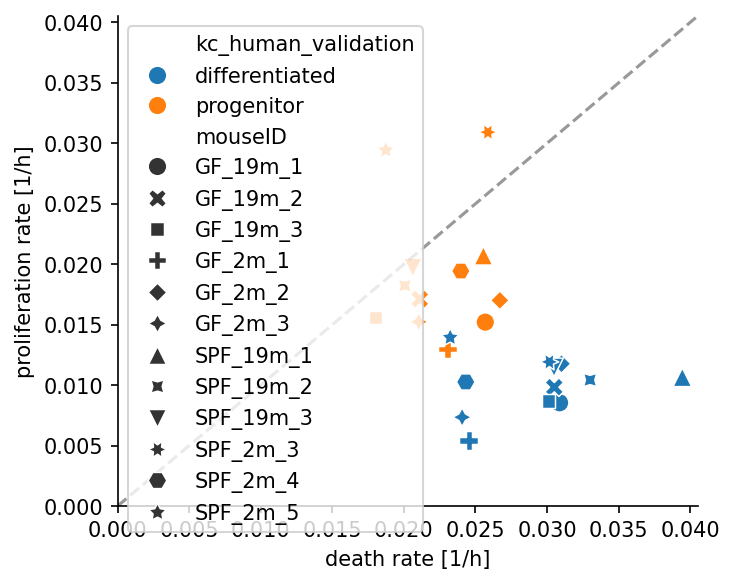

In [ ]:
mart = pd.read_csv(
    '/scratch/common/miniconda3/envs/scx_py310/lib/python3.10/site-packages/classifier_data/mart_export_gene_names.txt',
    sep='\t',
)
symbol_to_ensembl = dict(zip(mart['Mouse gene name'], mart['Mouse gene stable ID']))

tidyi_kc = mukin_kc[:, mukin_kc.var_names.isin(symbol_to_ensembl)].copy()
tidyi_kc.layers['counts'] = tidyi_kc.layers['raw'].copy()
tidyi_kc.var_names = [symbol_to_ensembl[g] for g in tidyi_kc.var_names]
tidyi_kc.var_names_make_unique()
tidyi_kc.obs['mouse_kc_human_validation'] = [
    f'{mouse}_{annot}' for mouse, annot in zip(tidyi_kc.obs['mouseID'], tidyi_kc.obs['kc_human_validation'])
]

tm = tidyi_main_mouse.tidy_rates_mouse(gene_list=tidyi_kc.var_names.tolist())
tm.train_classifier()

tidyi_rates = []
for group in tidyi_kc.obs['mouse_kc_human_validation'].unique():
    cells = tidyi_kc.obs['mouse_kc_human_validation'] == group
    prolif_rate, death_rate, _, _ = tm.apply_classifier(tidyi_kc[cells].copy())
    mouse_id, annotation = group.rsplit('_', 1)
    tidyi_rates.append([mouse_id, annotation, prolif_rate, death_rate, cells.sum()])

tidyi_rates = pd.DataFrame(
    tidyi_rates,
    columns=['mouseID', 'kc_human_validation', 'proliferation_rate', 'death_rate', 'n_cells'],
)
display(tidyi_rates)


In [31]:
tidyi_rates[['model', 'age']] = tidyi_rates['mouseID'].str.extract(r'^(GF|SPF)_(2m|19m)_')
tidyi_rates.to_csv(output_dir / 'tidyi_rates_kc_human_validation.csv', index=False)
display(tidyi_rates)


,mouseID,kc_human_validation,proliferation_rate,death_rate,n_cells,model,age
0,GF_19m_1,differentiated,0.008543,0.030876,3705,GF,19m
1,GF_19m_1,progenitor,0.015211,0.025687,2606,GF,19m
2,GF_19m_2,progenitor,0.017113,0.021109,1308,GF,19m
3,GF_19m_2,differentiated,0.009830,0.030505,1760,GF,19m
4,GF_19m_3,differentiated,0.008696,0.030112,2076,GF,19m
5,GF_19m_3,progenitor,0.015619,0.018038,1706,GF,19m
6,GF_2m_1,differentiated,0.005422,0.024524,2028,GF,2m
7,GF_2m_1,progenitor,0.012980,0.023053,1244,GF,2m
8,GF_2m_2,differentiated,0.011769,0.031009,964,GF,2m
9,GF_2m_2,progenitor,0.017012,0.026705,1011,GF,2m


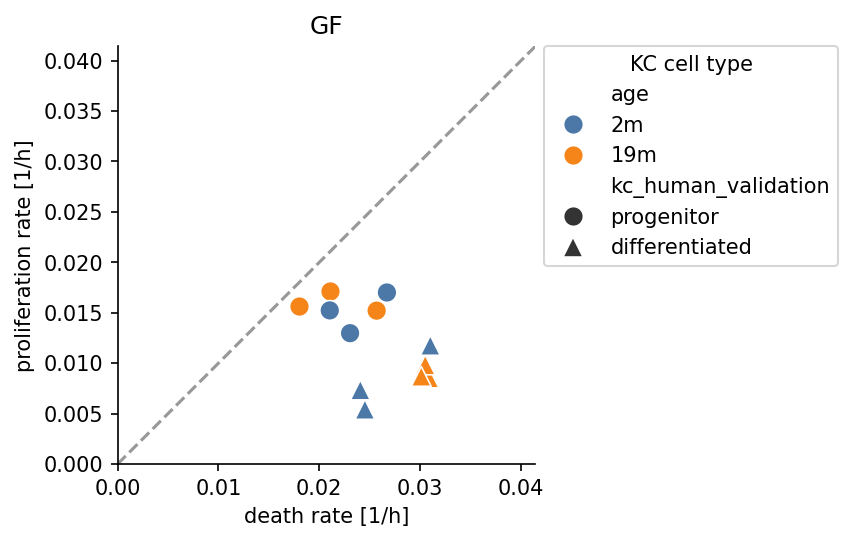

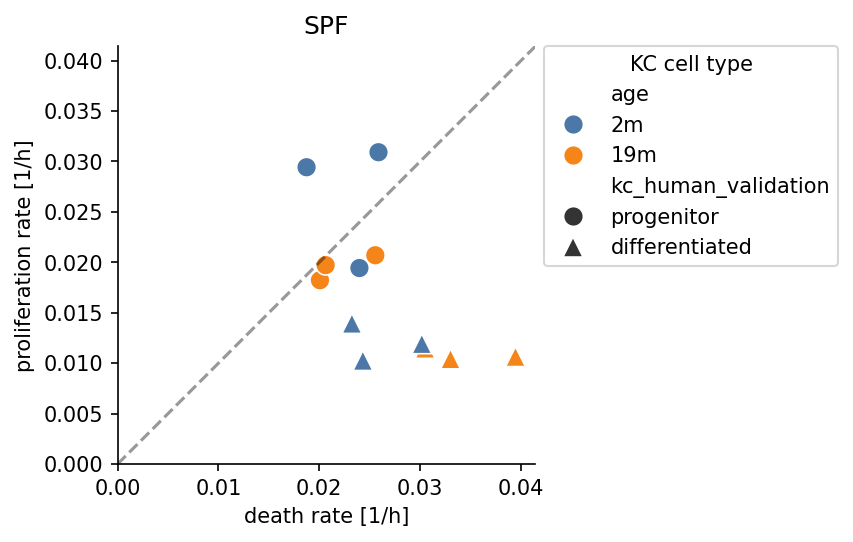

In [33]:
lim = tidyi_rates[['death_rate', 'proliferation_rate']].to_numpy().max() * 1.05
age_order = ['2m', '19m']
kc_order = ['progenitor', 'differentiated']
palette = {'2m': '#4C78A8', '19m': '#F58518'}
markers = {'progenitor': 'o', 'differentiated': '^'}

for model in ['GF', 'SPF']:
    fig, ax = plt.subplots(figsize=(5, 4), dpi=150)
    sns.scatterplot(
        data=tidyi_rates[tidyi_rates['model'] == model],
        x='death_rate',
        y='proliferation_rate',
        hue='age',
        hue_order=age_order,
        palette=palette,
        style='kc_human_validation',
        style_order=kc_order,
        markers=markers,
        s=90,
        ax=ax,
    )
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.4)
    ax.set(xlim=(0, lim), ylim=(0, lim), title=model, xlabel='death rate [1/h]', ylabel='proliferation rate [1/h]')
    ax.set_aspect('equal', adjustable='box')
    ax.legend(title='KC cell type', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    sns.despine()
    fig.tight_layout()
    fig.savefig(output_dir / f'tidyi_rates_kc_human_validation_scatter_{model}.png', dpi=300, bbox_inches='tight')
    plt.show()
